In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('D:/Important Files/Machine Learning/Datasets/HAR.csv')
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [3]:
df.shape

(7352, 563)

In [4]:
df['Activity'].value_counts()

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

In [5]:
X = df.drop(columns=['subject', 'Activity'])
y_raw = df['Activity']

## Preprocessing stage:

In [6]:
le = LabelEncoder()
y = le.fit_transform(y_raw)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
X_train.shape, X_test.shape

((5881, 561), (1471, 561))

In [9]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [10]:
knn = KNeighborsClassifier()

knn.fit(X_train_s, y_train)
baseline_acc = accuracy_score(y_test, knn.predict(X_test_s))
print(f"Baseline accuracy (561 features): {baseline_acc:.4f}")

Baseline accuracy (561 features): 0.9646


## PCA (Recap):

In [11]:
pca_full = PCA().fit(X_train_s)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cum_var >= 0.95) + 1
print(f"Components needed for 95% variance: {n_95}")

Components needed for 95% variance: 101


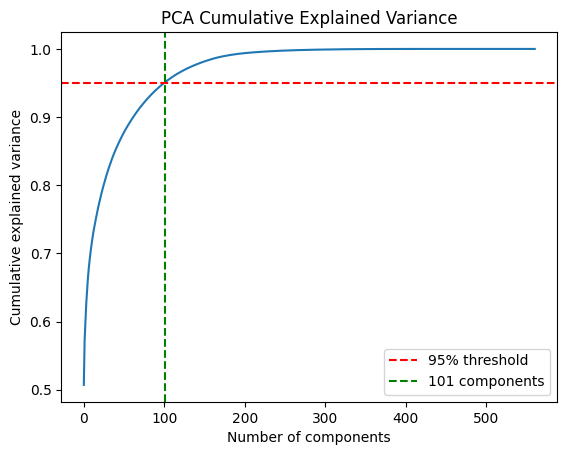

In [12]:
plt.plot(cum_var)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.axvline(x=n_95, color='g', linestyle='--', label=f'{n_95} components')
plt.legend()
plt.title('PCA Cumulative Explained Variance')
plt.show()

In [13]:
pca = PCA(n_components=n_95, random_state=42)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)

In [14]:
knn_pca = KNeighborsClassifier()
knn_pca.fit(X_train_pca, y_train)
pca_acc = accuracy_score(y_test, knn_pca.predict(X_test_pca))
print(f"PCA ({n_95} components) accuracy: {pca_acc:.4f}")

PCA (101 components) accuracy: 0.9613


### PCA 2D Visualization:

In [15]:
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca2 = pca_2d.fit_transform(X_train_s)

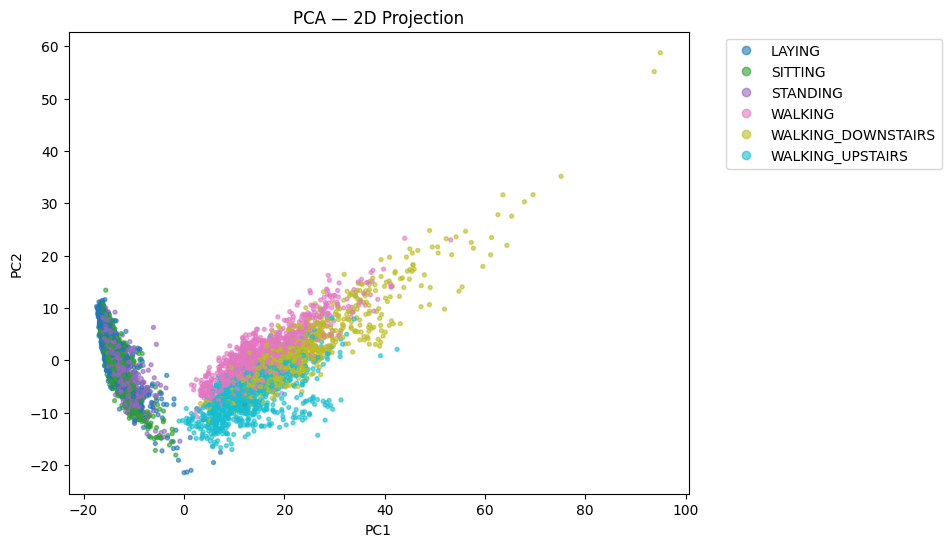

In [16]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_train_pca2[:,0], X_train_pca2[:,1], c=y_train, cmap='tab10', s=8, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA — 2D Projection')
plt.legend(handles=scatter.legend_elements()[0], labels=list(le.classes_), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## LDA (Linear Discriminant Analysis):

In [17]:
lda = LinearDiscriminantAnalysis(n_components=5)
X_train_lda = lda.fit_transform(X_train_s, y_train)
X_test_lda = lda.transform(X_test_s)

In [18]:
knn_lda = KNeighborsClassifier()
knn_lda.fit(X_train_lda, y_train)
lda_acc = accuracy_score(y_test, knn_lda.predict(X_test_lda))
print(f"LDA (5 components) accuracy: {lda_acc:.4f}")

LDA (5 components) accuracy: 0.9823


### LDA 2D Visualization:

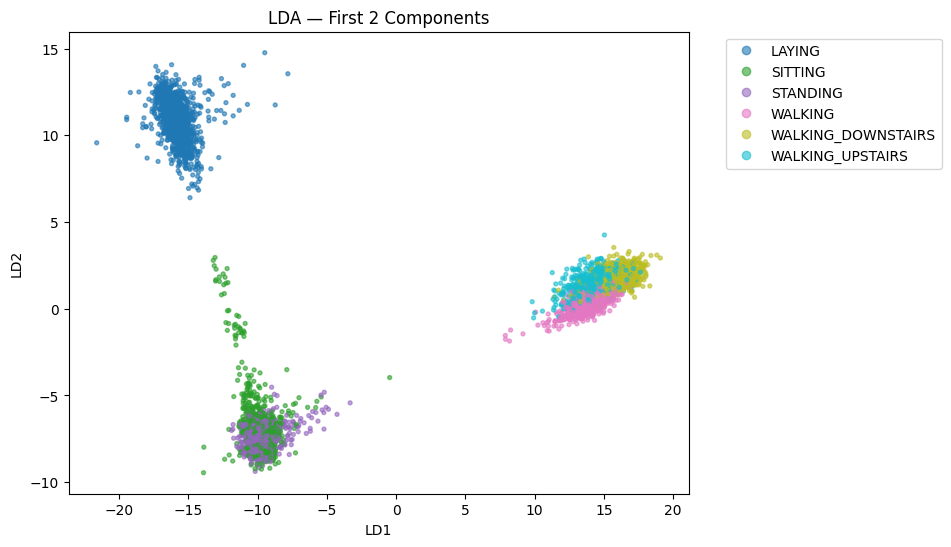

In [19]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_train_lda[:,0], X_train_lda[:,1], c=y_train, cmap='tab10', s=8, alpha=0.6)
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('LDA — First 2 Components')
plt.legend(handles=scatter.legend_elements()[0], labels=list(le.classes_), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()